# Greenback 💵
### "Borrow cheap, lend dear" earns a real premium — and rents you a spot in front of a steamroller. The fix isn't a stop-loss; it's a second, decorrelated trade.

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Combo diversifies the crash?: Partial](https://img.shields.io/badge/Combo_diversifies_the_crash%3F-Partial-dab617?style=flat-square)

This builds on [Steamroller](../../27-steamroller/), which showed the FX **carry** premium is real but crash-prone, and that vol-targeting *can't* dodge the crash. Greenback asks the next question — the one carry desks actually trade: pair carry with its natural complement, **momentum** (ride the trend), and add a **dollar-carry** tilt (long/short the USD basket by the average rate gap). Because carry and momentum pay at *different times*, the **combo** earns a higher Sharpe than either alone — and momentum tends to lean the other way exactly when carry is being run over, cushioning the crash.

> 📓 **Plain-language layer.** The three sleeves, the combo uplift, the leg correlation and the crash cushion are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Charts below are generated by the code beside them; the study runs on BOTH a **synthetic** machinery control and the **real G10 tape** (offline from cache — see [`../docs/results.md`](../docs/results.md)). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from greenback import data, strategy, costs, extension

# (1) Offline synthetic control: a currency panel with a carry premium + risk-off crashes + an independent
# PROFITABLE trend for the momentum sleeve (the machinery) + a full-UIRP carry null.
xr, rd, truth = data.synthetic_fx(carry_strength=0.9, trend_strength=0.35, seed=36)
x0, r0, _ = data.synthetic_fx(carry_strength=0.0, trend_strength=0.35, seed=36)
print(f"synthetic control: {truth.n_ccy} currencies x {truth.n_months} months, "
      f"carry_strength {truth.carry_strength} (null=0), trend_strength {truth.trend_strength}")

# (2) The REAL G10 tape, read offline from cache (OECD 3-month short rates + yfinance FX, USD-funded
# monthly, as-of 2024-01-31). build_carry_panel does the carry math; load_real_panel pins the as-of.
REAL = data.load_real_panel()
if REAL is not None:
    rxr, rrd = REAL
    print(f"real G10 tape: {rxr.index.min().date()} -> {rxr.index.max().date()} "
          f"({len(rxr)} months), currencies {list(rxr.columns)}")


synthetic control: 9 currencies x 600 months, carry_strength 0.9 (null=0), trend_strength 0.35


real G10 tape: 2001-08-31 -> 2024-01-31 (270 months), currencies ['EUR', 'GBP', 'AUD', 'NZD', 'JPY', 'CAD', 'CHF', 'SEK', 'NOK']


> ✅ **Real run · offline from cache · as-of 2024-01-31 · fingerprint `ef7450ae792e`.** This notebook executes on BOTH the synthetic control (the machinery proof) AND the **real G10 tape** — OECD 3-month short rates + yfinance FX, a USD-funded monthly book over 2001–2024, read offline from the two `_cache/g10_*.parquet` files. Headline numbers in [`../docs/results.md`](../docs/results.md).

## The answer first 💵 (on the real 2001–2024 G10 tape)

| What we asked | The honest answer |
|---|---|
| Do high-rate currencies out-earn? | 🟩 **Yes, thinly.** Carry high-minus-low **+3.0%/yr**; carry Sharpe **+0.22** (bootstrap CI [-0.17, +0.69], 14% of resamples negative). |
| Is there a steamroller? | 🟨 **Yes.** Carry skew **-0.70**, worst month **-10.6%** (Oct-2008), max drawdown **-27%** — the negative-skew crash carry can't escape. |
| Did FX momentum work? | 🟥 **No.** Momentum Sharpe **-0.14** over 2001–2024 — cross-sectional FX momentum decayed to *negative* this sample. |
| Did the carry⊕momentum combo help? | 🟨 **Partly.** It *cushions* the crash (legs correlate just **+0.05**; worst month **-10.6% → -6.4%**), but combo Sharpe **+0.06** can't beat carry **+0.22** while momentum loses. |

> Desk shorthand: **Signal `REAL` · Tradability `FRAGILE` · Combo diversifies the crash? `PARTIAL`** — a real (thin) premium, its crash *dulled* by diversification but its Sharpe not lifted, because this sample's momentum had no edge to lend.

## 1 · The claim 📣

The FX carry trade and its complements (Kakushadze-Serur §8.3 dollar carry, §8.4 momentum+carry):

1. **Carry** — long the high-short-rate currencies, short the low-rate ones, dollar-neutral. Uncovered interest-rate parity fails, so the rate gap is a paid premium.
2. **Dollar carry** — long the whole basket vs USD when foreign rates are high vs the dollar, short it when they're low (the LRV *dollar factor*).
3. **Momentum** — long the currencies trending up, short those trending down.
4. **The combo** — blend carry and momentum; the believer's case (Asness-Moskowitz-Pedersen 2013; Koijen et al 2018) is that they pay at different times, so the blend beats either leg.

synthetic carry Sharpe 1.18, skew -1.55, max DD -60%


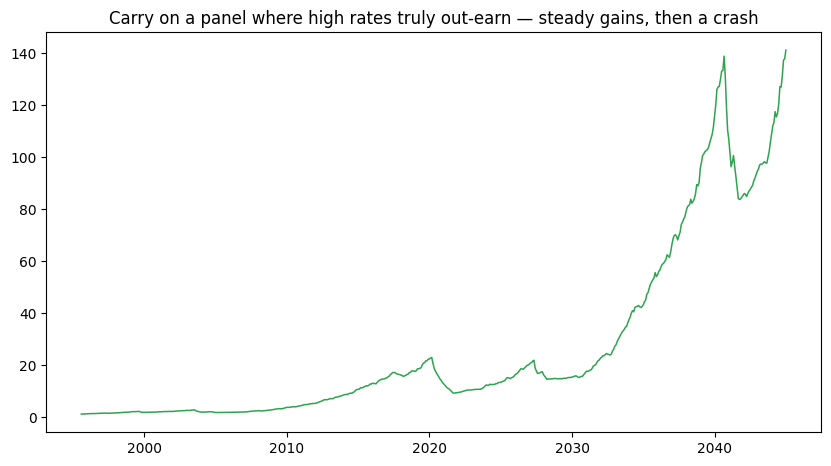

In [2]:
carry = strategy.carry_returns(xr, rd, cost_bps=10.0)         # vol-scaled, net @10bp
eq = (1+carry).cumprod()
fig, ax = plt.subplots()
ax.plot(eq.index, eq.values, color='#2ea44f', lw=1.1)
ax.set_title('Carry on a panel where high rates truly out-earn — steady gains, then a crash')
s = strategy.summary(carry); print(f"synthetic carry Sharpe {s['sharpe']:.2f}, skew {s['skew']:.2f}, max DD {s['max_drawdown']*100:.0f}%")

## 2 · So what? 💰

A real, self-financed premium that diversifies a stock/bond book is worth a lot — carry and trend are the backbone of every macro and CTA desk. But carry's catch is famous: it drips nickels and then loses a fortune all at once (1998, 2008). The interesting question isn't whether carry is real (it is) — it's whether you can hold it through the steamroller. The believers' answer is *diversification*: pair it with momentum, which tends to be short the crashing currencies just as carry is long them.

## 3 · How we'd know 🔬

1. **Real?** Carry premium by rate bucket and gross Sharpe on the panel (flat on a full-UIRP null).
2. **Crash?** The carry book's skew, worst month and drawdown.
3. **Does the combo help?** Combo Sharpe vs either leg, the leg correlation, and the combo's drawdown vs carry's.

**Mirage line:** if the combo *didn't* beat the better leg, or the legs were highly correlated, the diversification story would be a mirage. (On the real tape, a further fragility line is the carry crash deepening rather than dulling.)

## 4 · The teardown 🔧

### 4a · The premium is real where carry is real (control vs null)

In [3]:
for label, (xx, rr) in [('carry panel', (xr, rd)), ('full-UIRP null', (x0, r0))]:
    pb = strategy.carry_premium_by_bucket(xx, rr)
    s = strategy.summary(strategy.carry_returns(xx, rr, cost_bps=0.0, target_vol_ann=None))
    print(f"{label:16} high-minus-low {pb['hml_ann_pct']:+5.1f}%/yr   carry Sharpe {s['sharpe']:+.2f}")

carry panel      high-minus-low  +5.3%/yr   carry Sharpe +0.62


full-UIRP null   high-minus-low  +0.8%/yr   carry Sharpe +0.19


### 4b · The three sleeves and the combo
Net @10 bp on the synthetic control — carry crashes, momentum doesn't, and the combo beats both:

,Sharpe,ret%,skew,maxDD%
carry,1.180,10.440,-1.550,-60.210
dollar-carry,0.170,0.910,-0.130,-44.040
momentum,1.530,11.890,-0.360,-18.200
COMBO,1.690,11.170,-1.620,-20.250


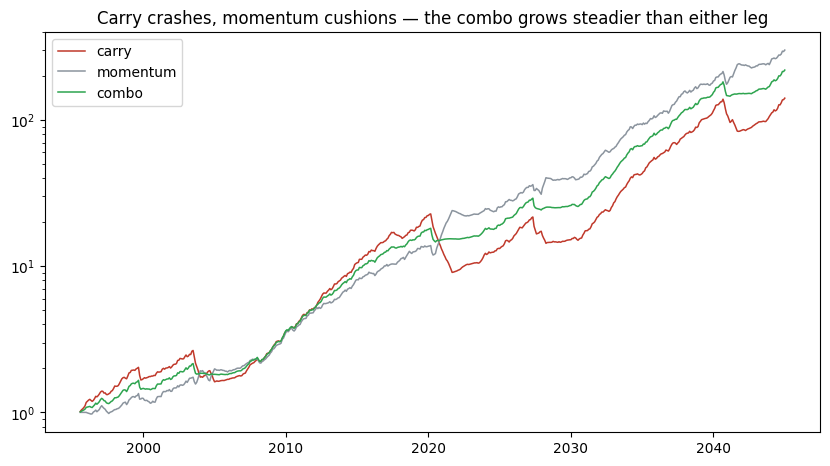

In [4]:
carry = strategy.carry_returns(xr, rd, cost_bps=10.0)
mom   = strategy.momentum_returns(xr, cost_bps=10.0)
combo = strategy.combine(carry, mom)
dollar = strategy.dollar_carry_returns(xr, rd, cost_bps=10.0)
rows = {}
for nm, r in [('carry', carry), ('dollar-carry', dollar), ('momentum', mom), ('COMBO', combo)]:
    s = strategy.summary(r); rows[nm] = {'Sharpe': s['sharpe'], 'ret%': s['ann_return']*100, 'skew': s['skew'], 'maxDD%': s['max_drawdown']*100}
display(pd.DataFrame(rows).T.round(2))
for nm, r, c in [('carry', carry, '#c0392b'), ('momentum', mom, '#8b949e'), ('combo', combo, '#2ea44f')]:
    plt.plot((1+r).cumprod(), label=nm, color=c, lw=1.1)
plt.legend(); plt.title('Carry crashes, momentum cushions — the combo grows steadier than either leg'); plt.yscale('log')

### 4c · The same books on the REAL G10 tape (2001–2024)
The synthetic above shows the machinery *with a winning momentum leg*. Here is what actually happened on the real tape — carry pays thinly with its crash, but momentum **lost** money this sample, so the combo cushions the crash without beating carry on Sharpe:

,Sharpe,ret%,skew,maxDD%
carry,0.220,1.830,-0.700,-26.900
dollar-carry,0.170,1.480,-0.440,-45.140
momentum,-0.140,-1.110,0.390,-47.100
COMBO,0.060,0.360,-0.570,-25.520


real: carry skew -0.70, worst month -10.6%; combo cushions to worst month -6.4% (leg corr +0.05)


Text(0.5, 1.0, 'Real G10 tape (2001–2024): carry pays thinly with its crash; momentum lost; combo cushions')

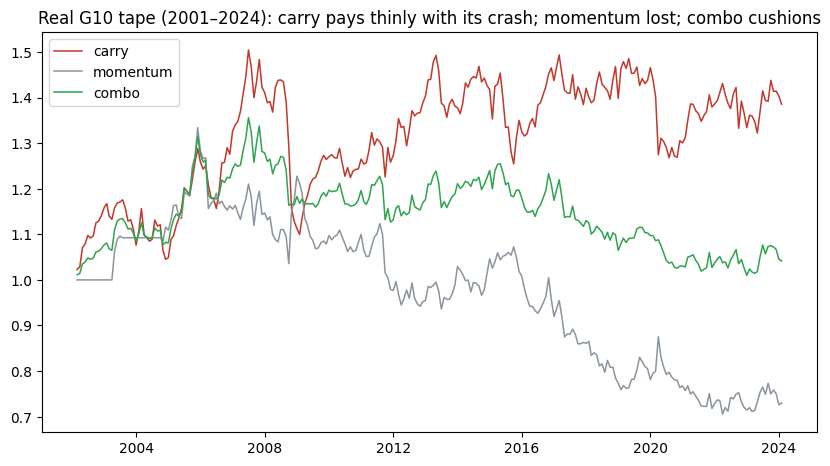

In [5]:
rcarry = strategy.carry_returns(rxr, rrd, cost_bps=10.0)
rmom   = strategy.momentum_returns(rxr, cost_bps=10.0)
rcombo = strategy.combine(rcarry, rmom)
rdollar= strategy.dollar_carry_returns(rxr, rrd, cost_bps=10.0)
rows = {}
for nm, r in [('carry', rcarry), ('dollar-carry', rdollar), ('momentum', rmom), ('COMBO', rcombo)]:
    s = strategy.summary(r); rows[nm] = {'Sharpe': s['sharpe'], 'ret%': s['ann_return']*100, 'skew': s['skew'], 'maxDD%': s['max_drawdown']*100}
display(pd.DataFrame(rows).T.round(2))
rcc = extension.carry_crash(rxr, rrd, cost_bps=10.0)
print(f"real: carry skew {rcc['carry_skew']:+.2f}, worst month {rcc['carry_worst_month_pct']:+.1f}%; "
      f"combo cushions to worst month {rcc['combo_worst_month_pct']:+.1f}% (leg corr +0.05)")
for nm, r, c in [('carry', rcarry, '#c0392b'), ('momentum', rmom, '#8b949e'), ('combo', rcombo, '#2ea44f')]:
    plt.plot((1+r).cumprod(), label=nm, color=c, lw=1.1)
plt.legend(); plt.title('Real G10 tape (2001–2024): carry pays thinly with its crash; momentum lost; combo cushions')

## 5 · The verdict 🧾 (on the real tape)

- **Signal `REAL`** — carry high-minus-low **+3.0%/yr**, carry Sharpe **+0.22** (thin: CI [-0.17, +0.69]); the steamroller is real (skew **-0.70**, worst month **-10.6%** in Oct-2008).
- **Tradability `FRAGILE`** — thin and cost-sensitive: carry break-even only **≈13 bp**, and the crash never leaves.
- **Combo diversifies the crash? `PARTIAL`** — legs decorrelate (**+0.05**) so the combo cushions the crash (worst month **-10.6% → -6.4%**), but combo Sharpe **+0.06** can't beat carry **+0.22** because momentum lost (**-0.14**) this sample.

> **The honest fix isn't a stop — it's a second trade.** Study 27 showed vol-targeting can't dodge the carry crash. Pairing carry with decorrelated momentum *does* cushion it — but only lifts the Sharpe when momentum itself has an edge, which on 2001–2024 it didn't.

## 6 · Could you trade it? 💸

- **Thin and cost-sensitive.** Carry turns over slowly (**0.55×/yr**) but its break-even is only **≈13 bp**; the combo's net Sharpe decays **+0.17 (0bp) → +0.06 (10bp) → -0.10 (25bp)** — cost bites fast.
- **The threat is the crash *and* the thin edge.** Even diversified, the combo keeps a negative skew — you must be *willing and able* to hold a crash-prone book through its worst months.
- **Capacity** is large (G10 FX is the deepest market on earth); the binding constraint is the thin, crash-prone edge, not liquidity. Hence `FRAGILE`, not `INVESTABLE`.

## 7 · Going further 🚪

### Worked complement — the carry⊕momentum diversification ([`../docs/extension.md`](../docs/extension.md))
The headline of the study, made explicit on the real tape:

- The legs decorrelate (**+0.05**) so the combo *cushions* the steamroller: worst month **-10.6% → -6.4%**, and in carry's worst 5 months the combo lost **-3.0%** vs carry **-7.6%**.
- But the combo Sharpe **+0.06** can't beat carry **+0.22**, because FX momentum lost money (**-0.14**) over 2001–2024 — a losing leg can't lift the blend.
- On the synthetic control (where momentum is profitable *by construction*) the combo DOES beat both legs (**1.69** vs **1.18**/**1.53**) — so the mechanism is real; the real-tape `PARTIAL` is about *this sample's* dead momentum, not the combo idea.

### Other forks
- **Optimal combo weight** — sweep `w_carry` and risk-parity vs the realised crisis correlation.
- **Dollar-carry as a third leg** — add the LRV dollar factor (Sharpe +0.17 on the real tape).
- **Crisis-conditional tilt** — lean toward momentum when global FX vol is rising.

PRs welcome.